In [1]:
%autoreload 2

In [8]:
from pipeline.subject import SubjectDataset

subject = SubjectDataset()

In [19]:
from nilearn.datasets import fetch_atlas_aal
aal = fetch_atlas_aal(version="3v2")

print(
    "AAL atlas nifti image (3D) "
    f" is located at: {aal['maps']}"
)

for i, label in enumerate(aal["labels"][1:]):
    if label == "Vermis_10":
        print(i)


[fetch_atlas_aal] Dataset found in /home/rongfei/nilearn_data/aal_3v2
AAL atlas nifti image (3D)  is located at: /home/rongfei/nilearn_data/aal_3v2/AAL3/AAL3v1.nii
115


In [10]:
import nibabel as nib
aal_data = nib.load(aal["maps"]).affine
aal_data

array([[  -2.,    0.,    0.,   90.],
       [   0.,    2.,    0., -126.],
       [   0.,    0.,    2.,  -72.],
       [   0.,    0.,    0.,    1.]])

In [11]:
image = subject.get_images()[0]
image_data = nib.load(image).affine
print(image_data)

[[   2.     0.     0.   -96.5]
 [   0.     2.     0.  -132.5]
 [   0.     0.     2.   -78.5]
 [   0.     0.     0.     1. ]]


In [ ]:
aal

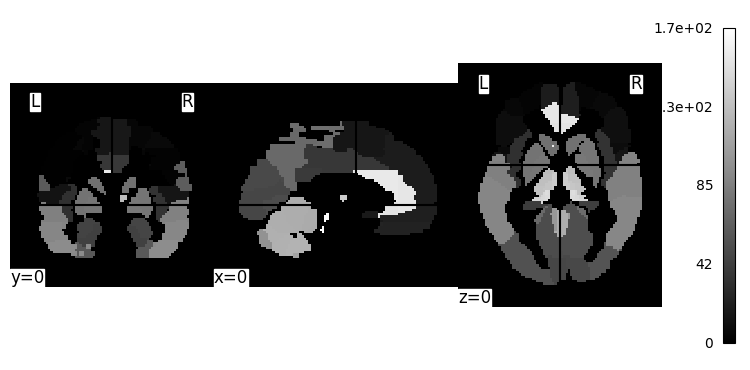

In [53]:
from nilearn.plotting import plot_img
from nilearn.image import index_img
plot_img(aal["maps"], cut_coords=(0, 0, 0))

/tmp/ipykernel_922146/1507793470.py:2: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_image = resample_to_img(image, aal["maps"], interpolation="nearest")
/tmp/ipykernel_922146/1507793470.py:2: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_image = resample_to_img(image, aal["maps"], interpolation="nearest")


(91, 109, 91, 176)
[[  -2.    0.    0.   90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]


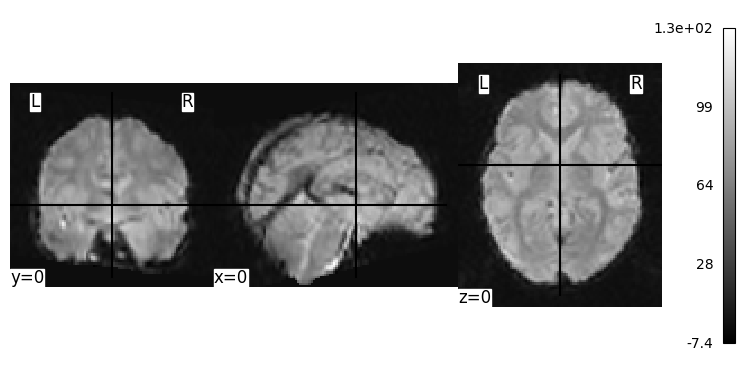

In [ ]:
from nilearn.image import resample_to_img
resampled_image = resample_to_img(image, aal["maps"], interpolation="nearest")
print(resampled_image.shape)
            # get upper triangular part
print(resampled_image.affine)
plot_img(index_img(resampled_image, 1), cut_coords=(0, 0, 0))

In [14]:
import numpy as np
x = np.zeros((176, 166))

# split the ts into 7 segments with 50% overlap
def split_ts(x, n_segments: int = 7):
    t = x.shape[0]
    n_segments = 7
    segment_size = 2 * t // (n_segments + 1)
    step = segment_size // 2  # 50% overlap

    segments = [x[i*step : i*step + segment_size] for i in range(n_segments)]
    return segments
print(len(split_ts(x)))


7


In [15]:
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker

# ConnectivityMeasure from Nilearn uses simple 'correlation' to compute
# connectivity matrices for all subjects in a list
def compute_connectivity(img):

    # resample the image to the aal atlas
    # resampled_image = resample_to_img(img, aal["maps"], interpolation="nearest")

    connectome_measure = ConnectivityMeasure(
        kind="correlation",
        standardize="zscore_sample",
    )

    masker = NiftiLabelsMasker(
        aal["maps"],  # Both hemispheres
        labels=aal["labels"],
        standardize="zscore_sample",
        memory="nilearn_cache",
        n_jobs=-1,
    )

    ts = masker.fit_transform(img)
    connectome = connectome_measure.fit_transform(split_ts(ts))
    return connectome


In [16]:
import numpy as np
from nilearn import plotting

connectome1 = compute_connectivity(image)

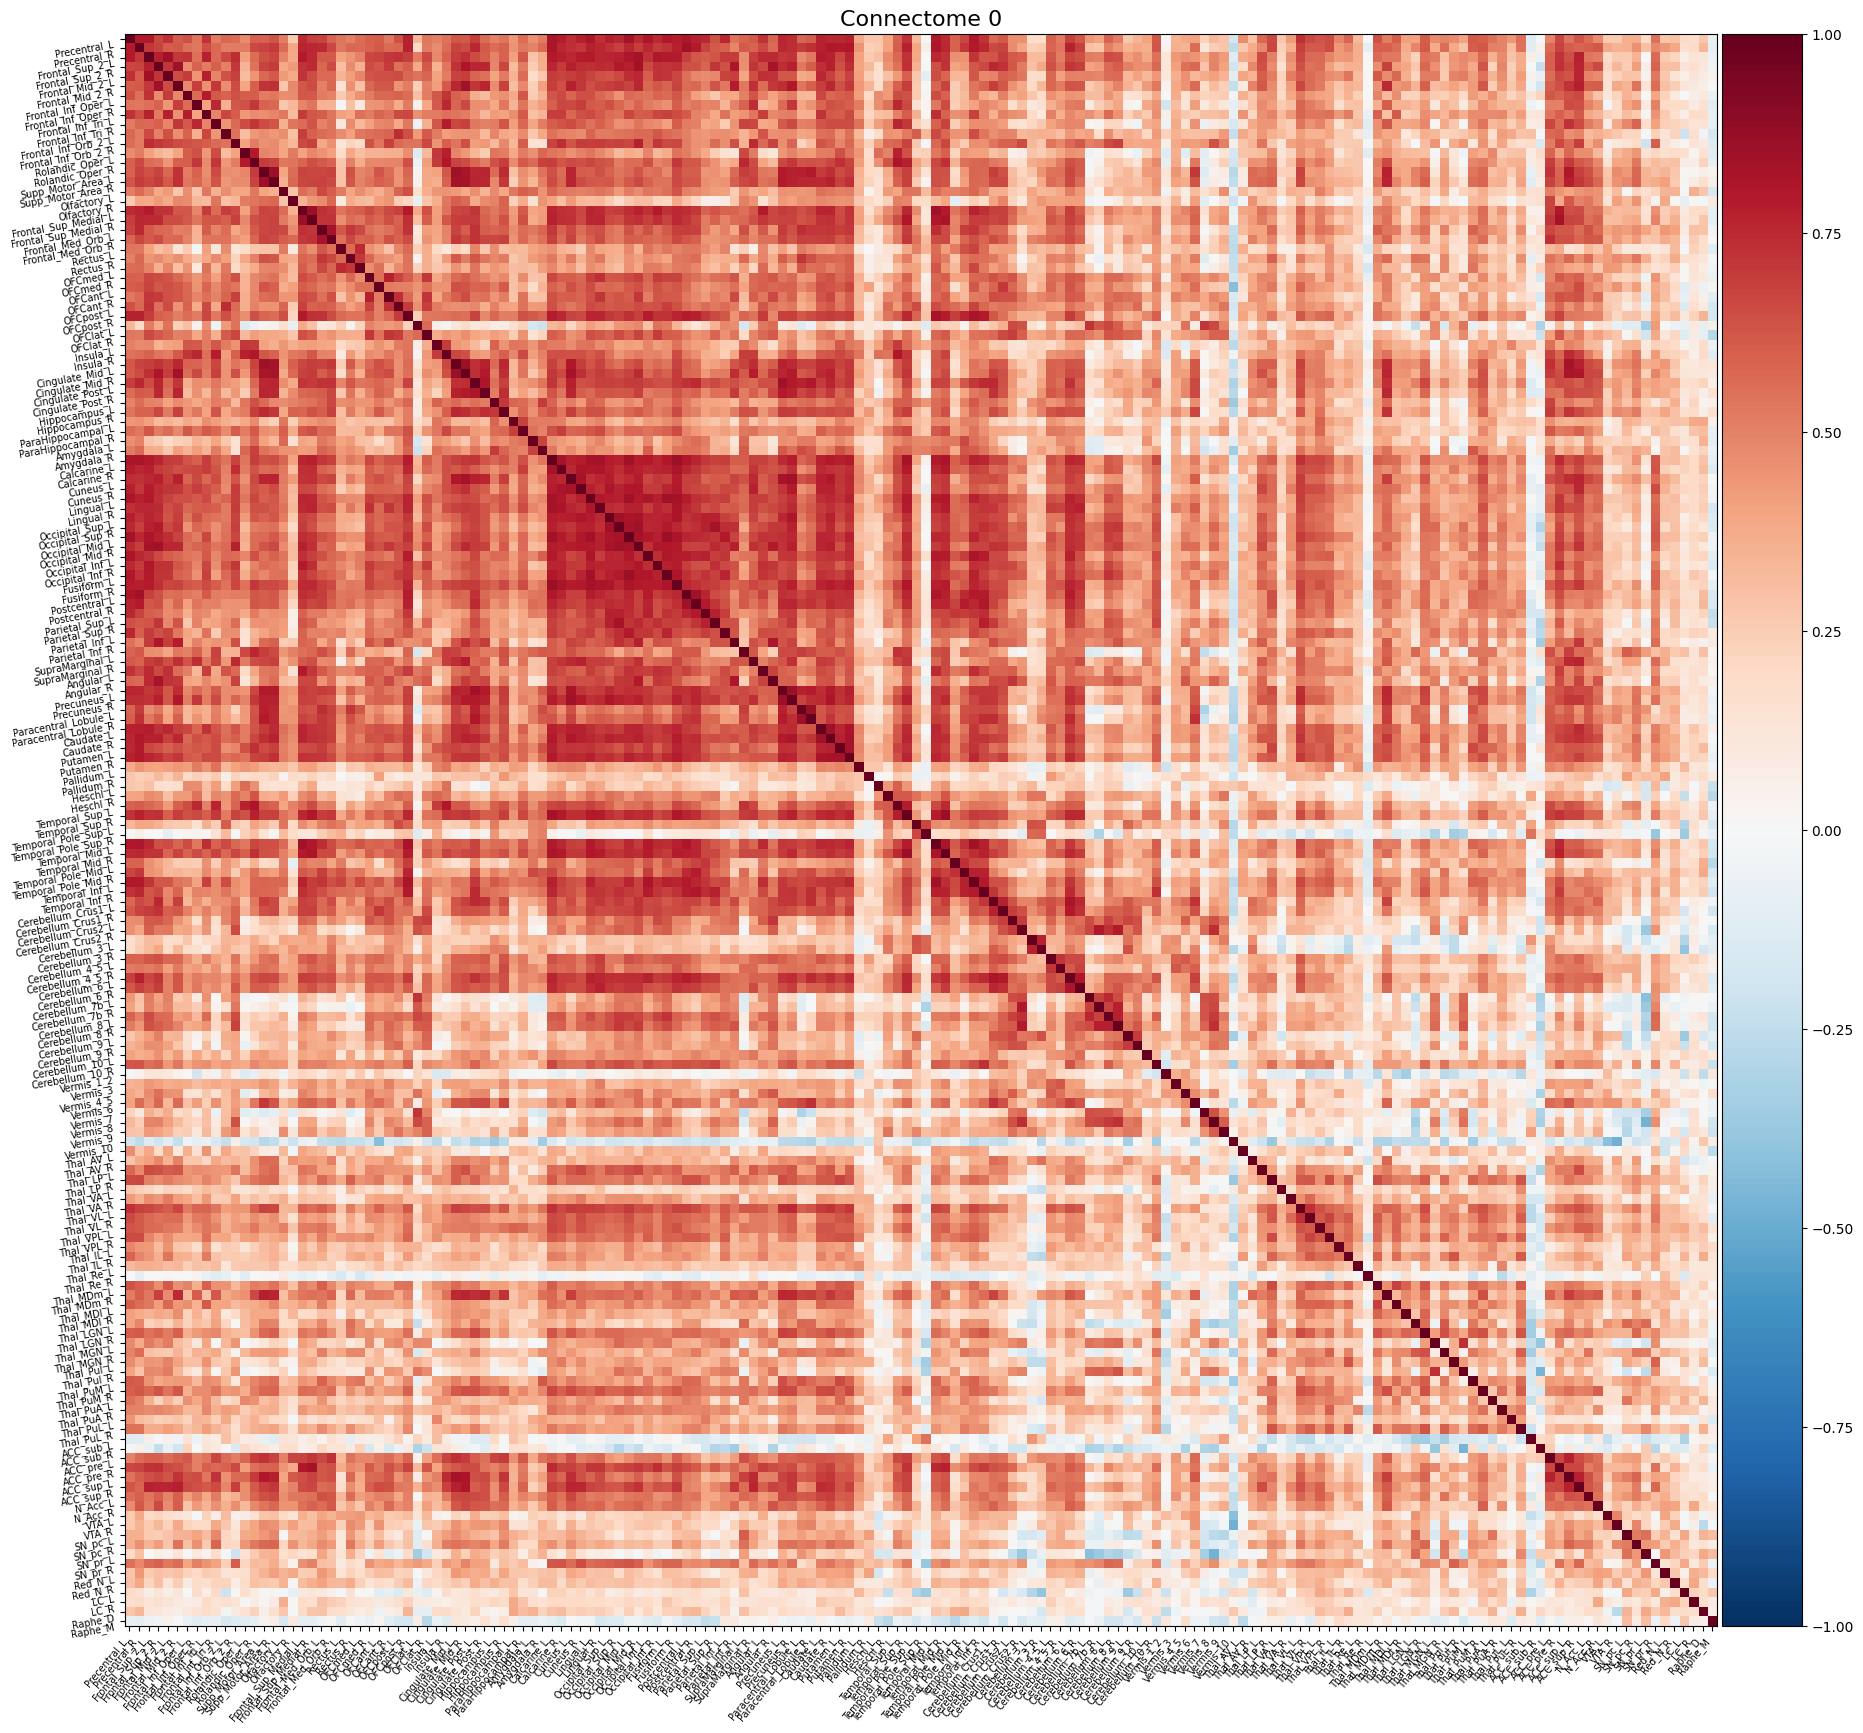

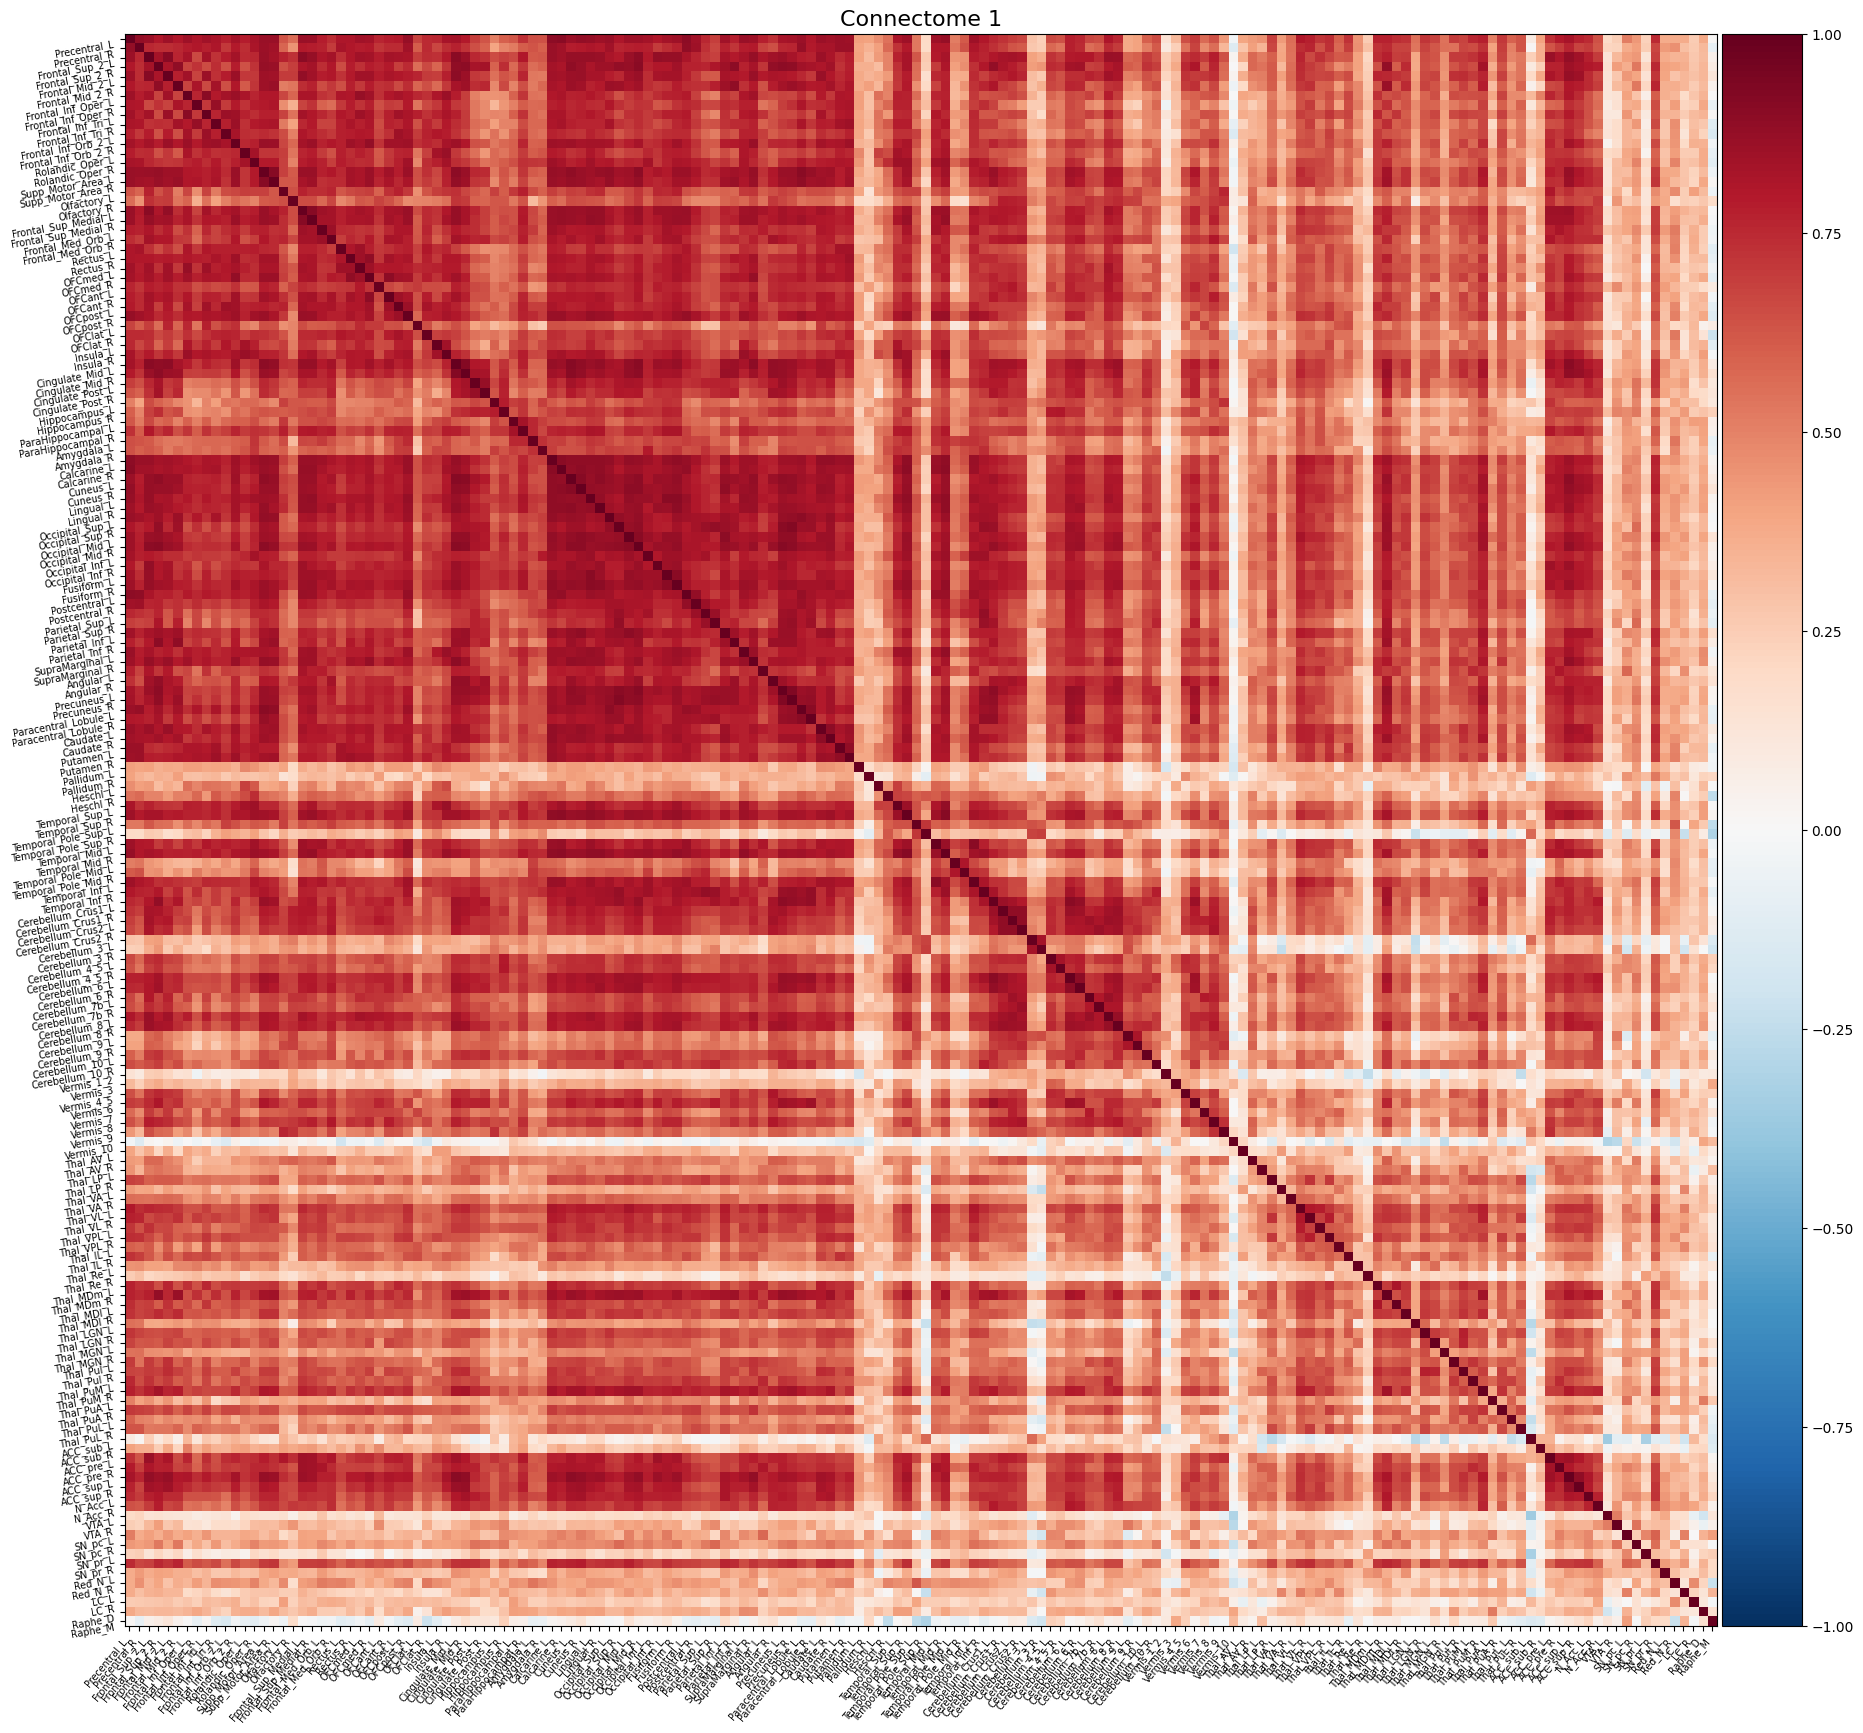

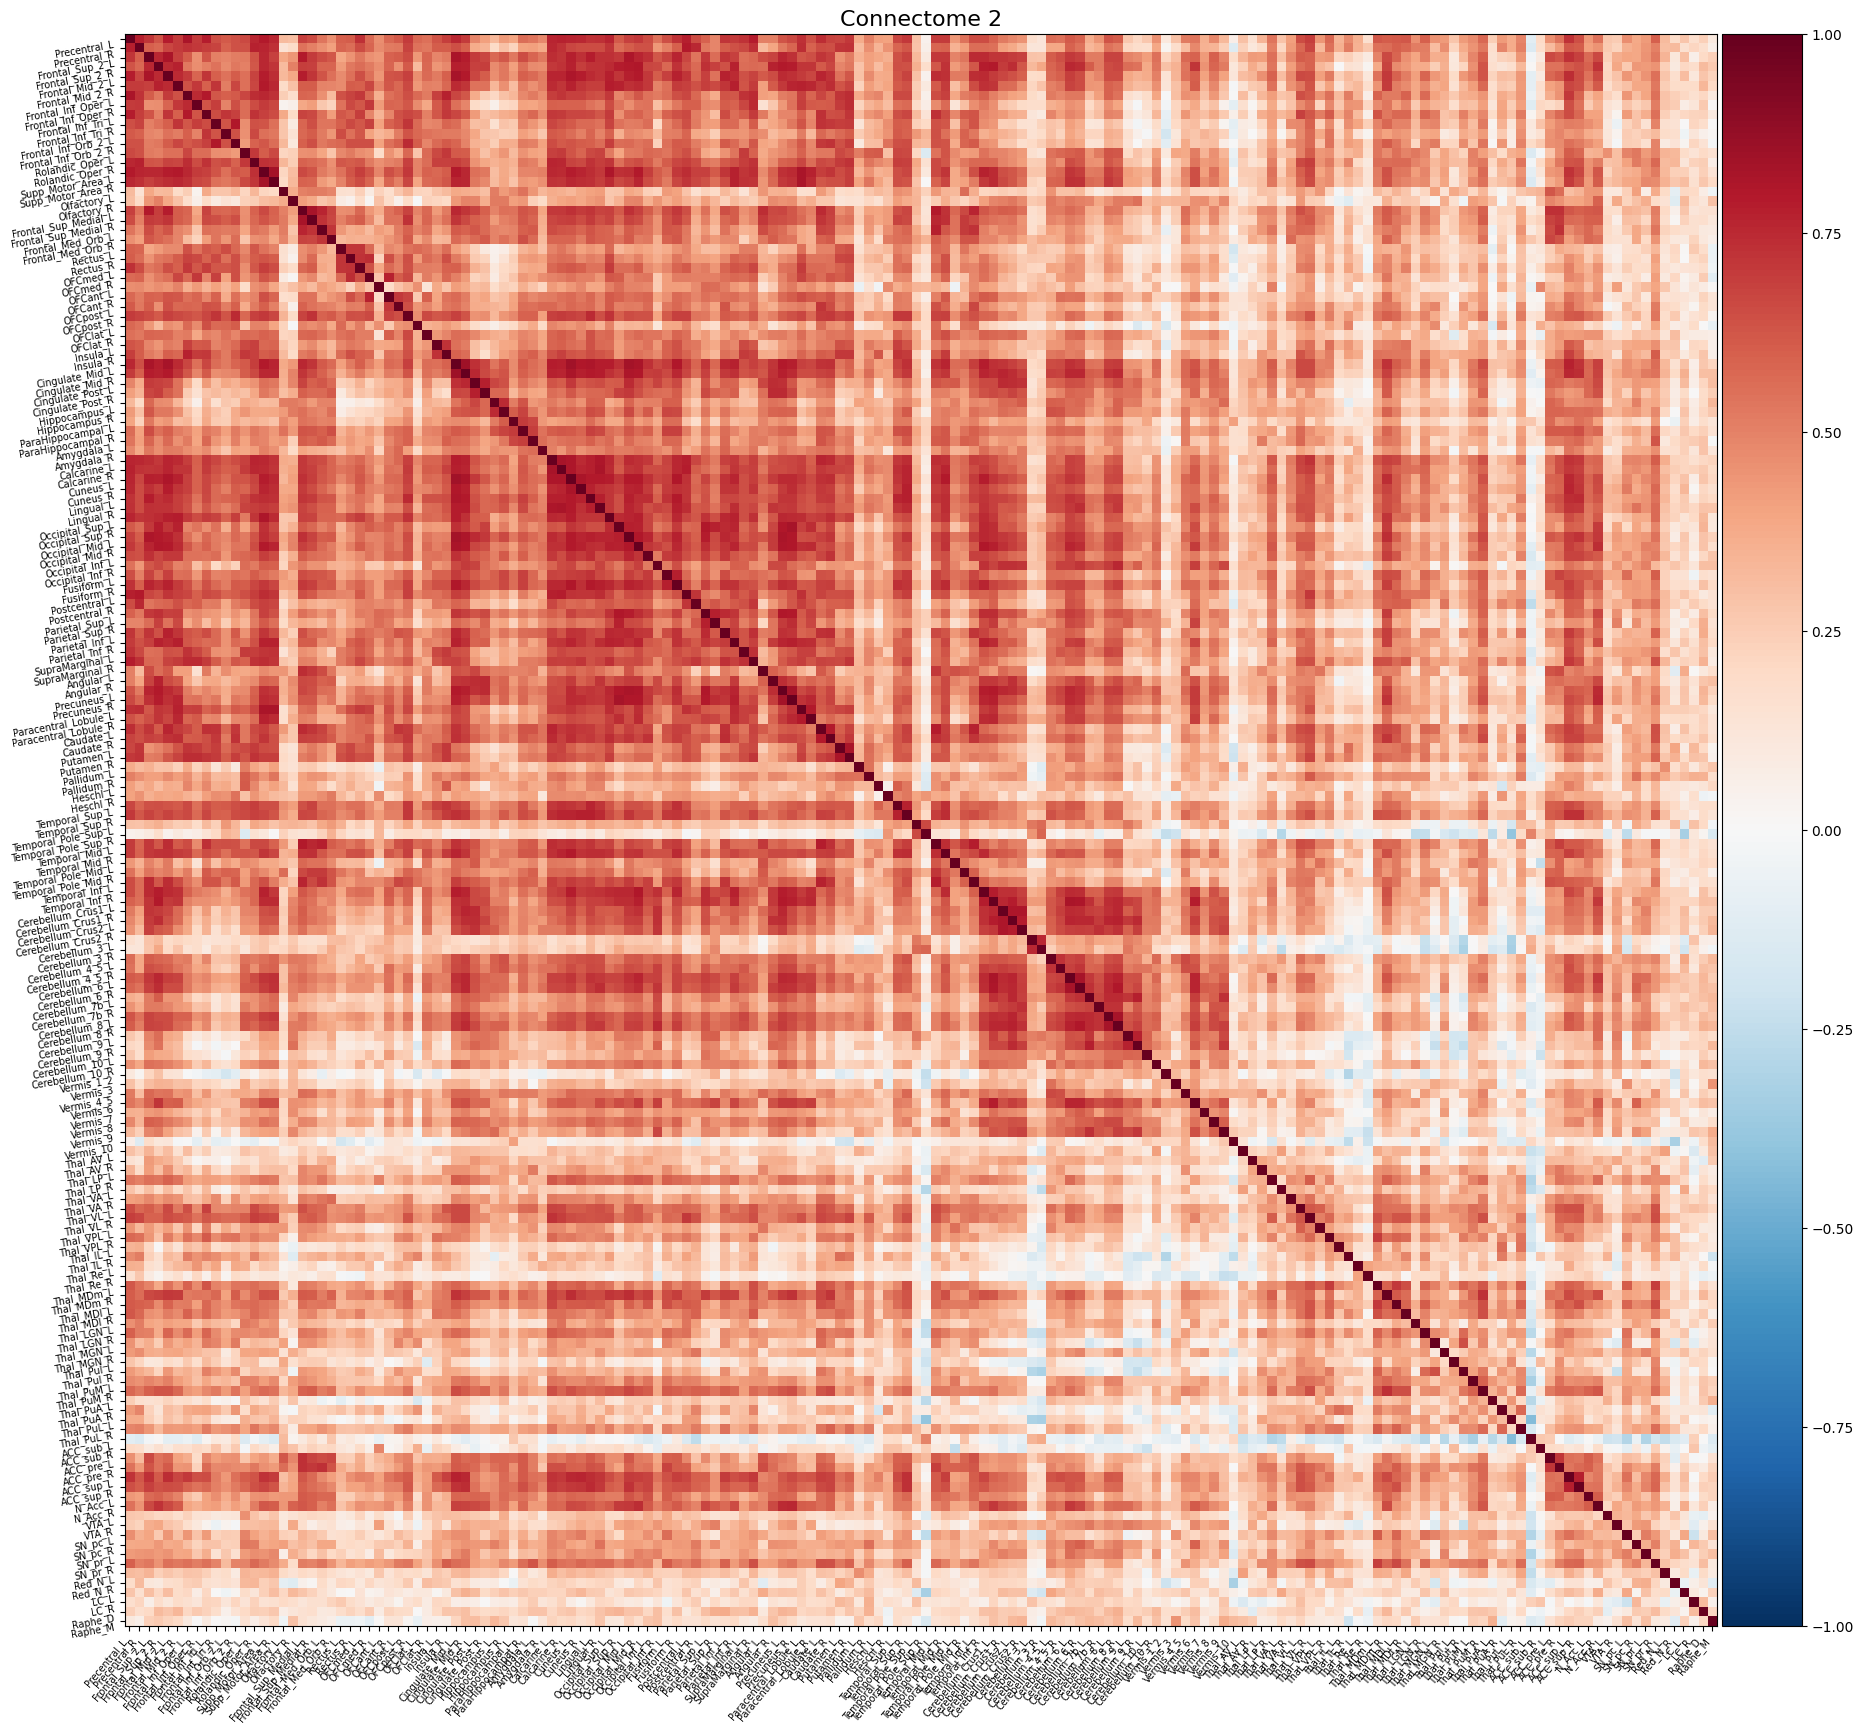

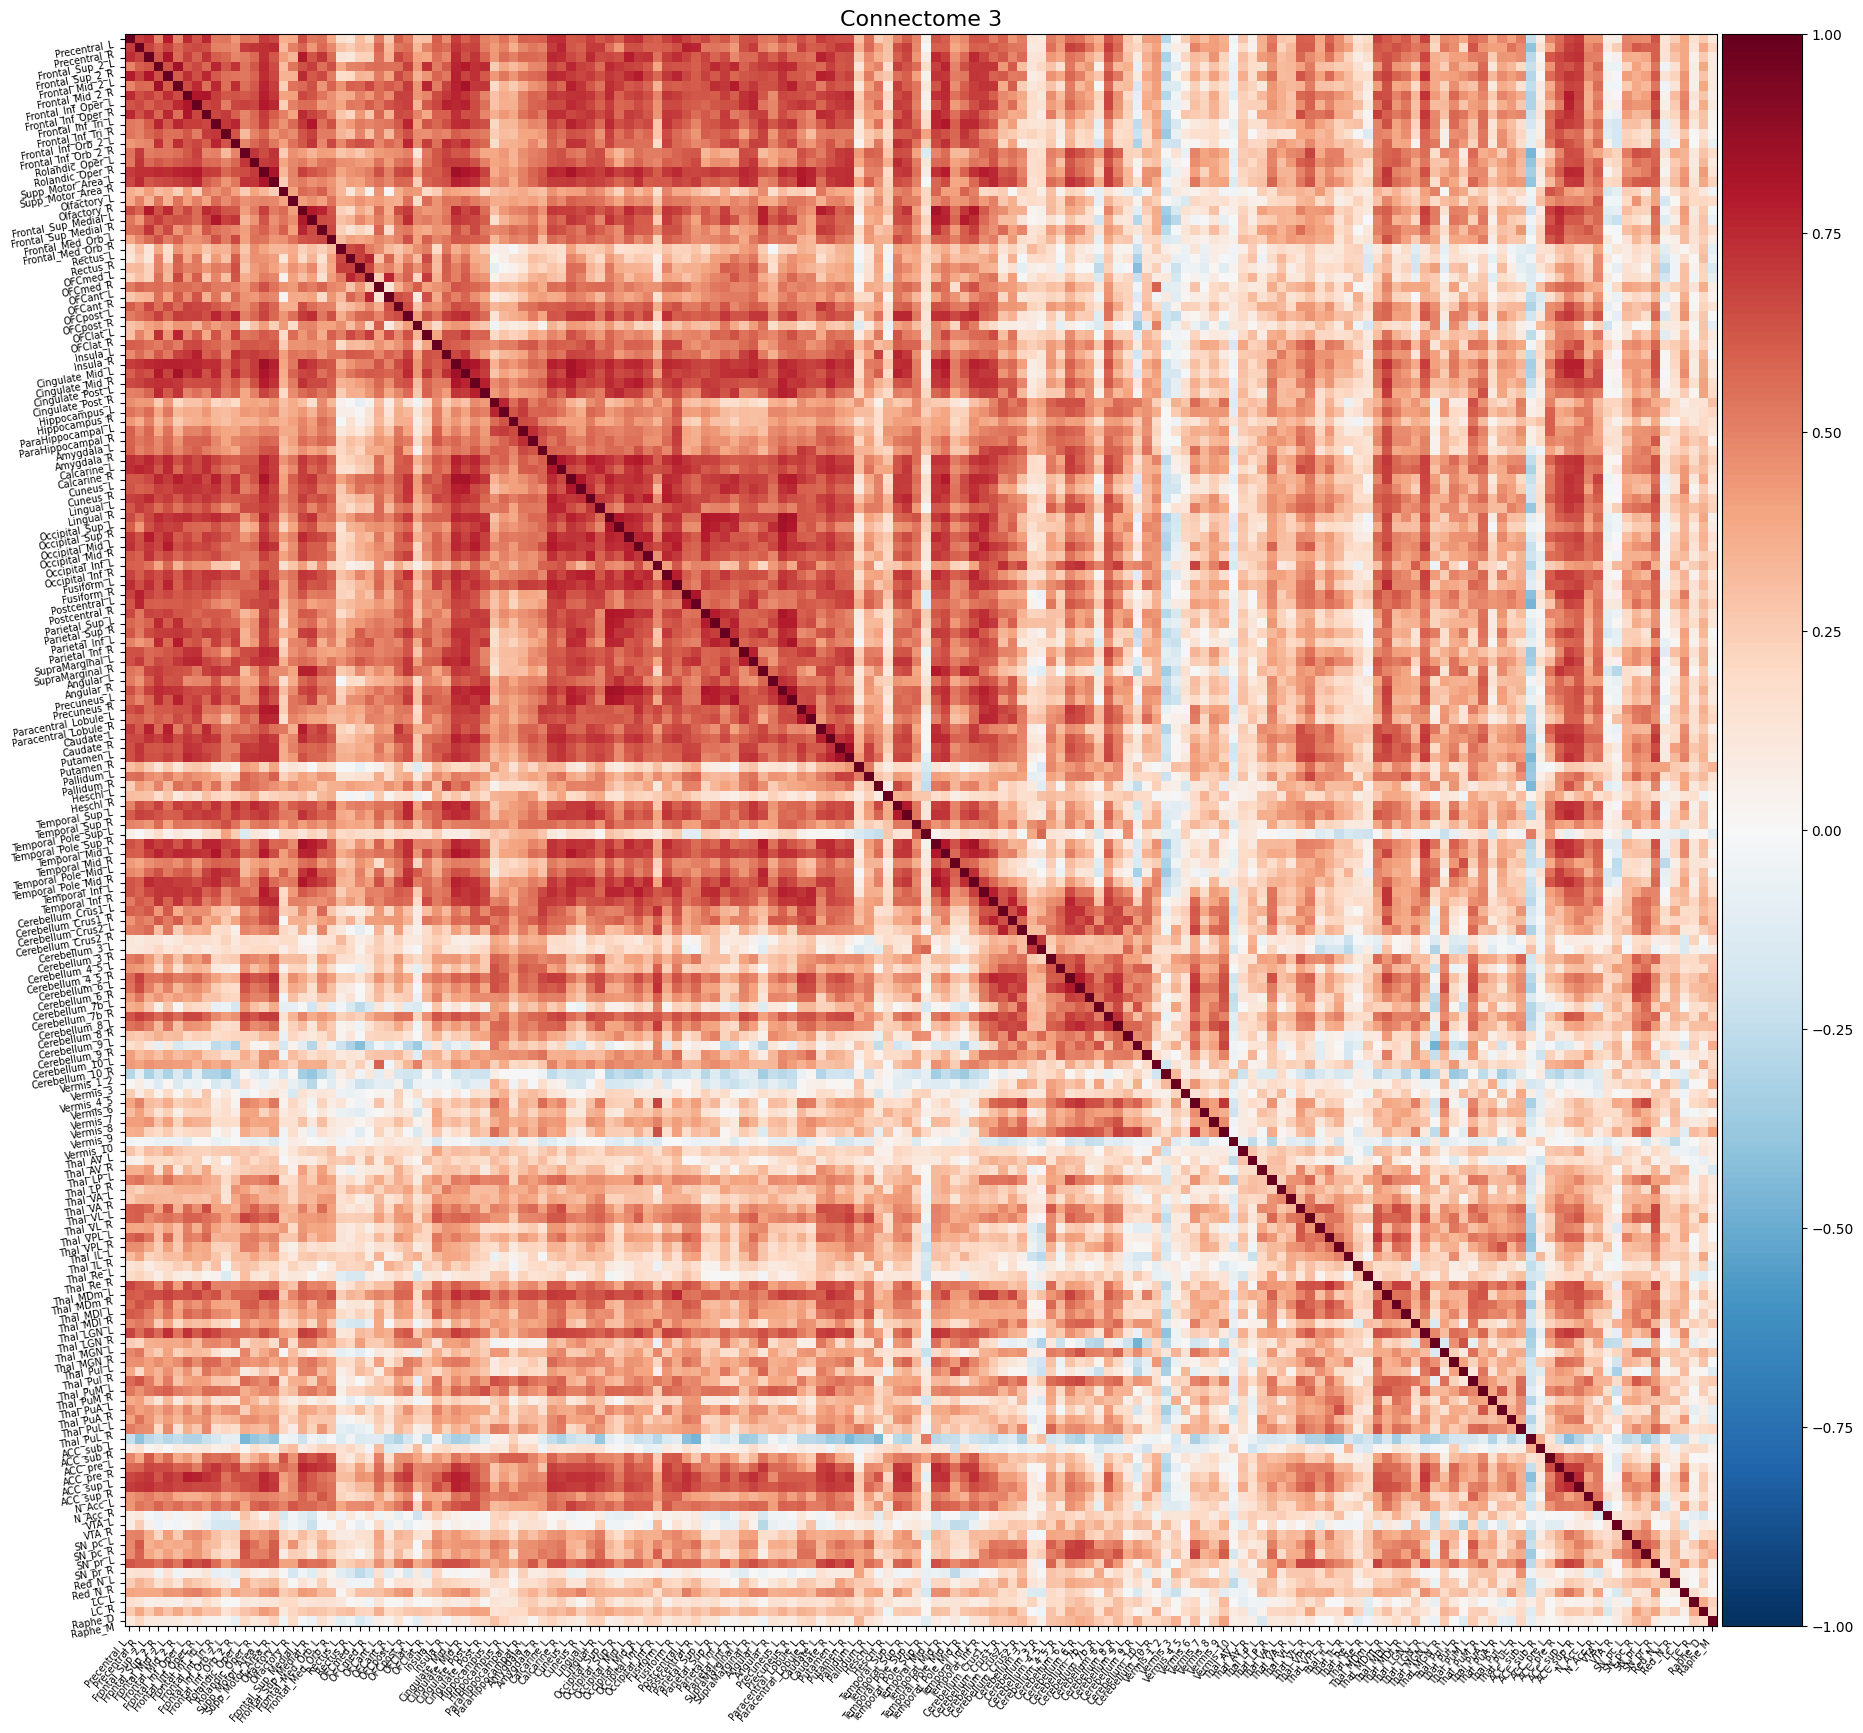

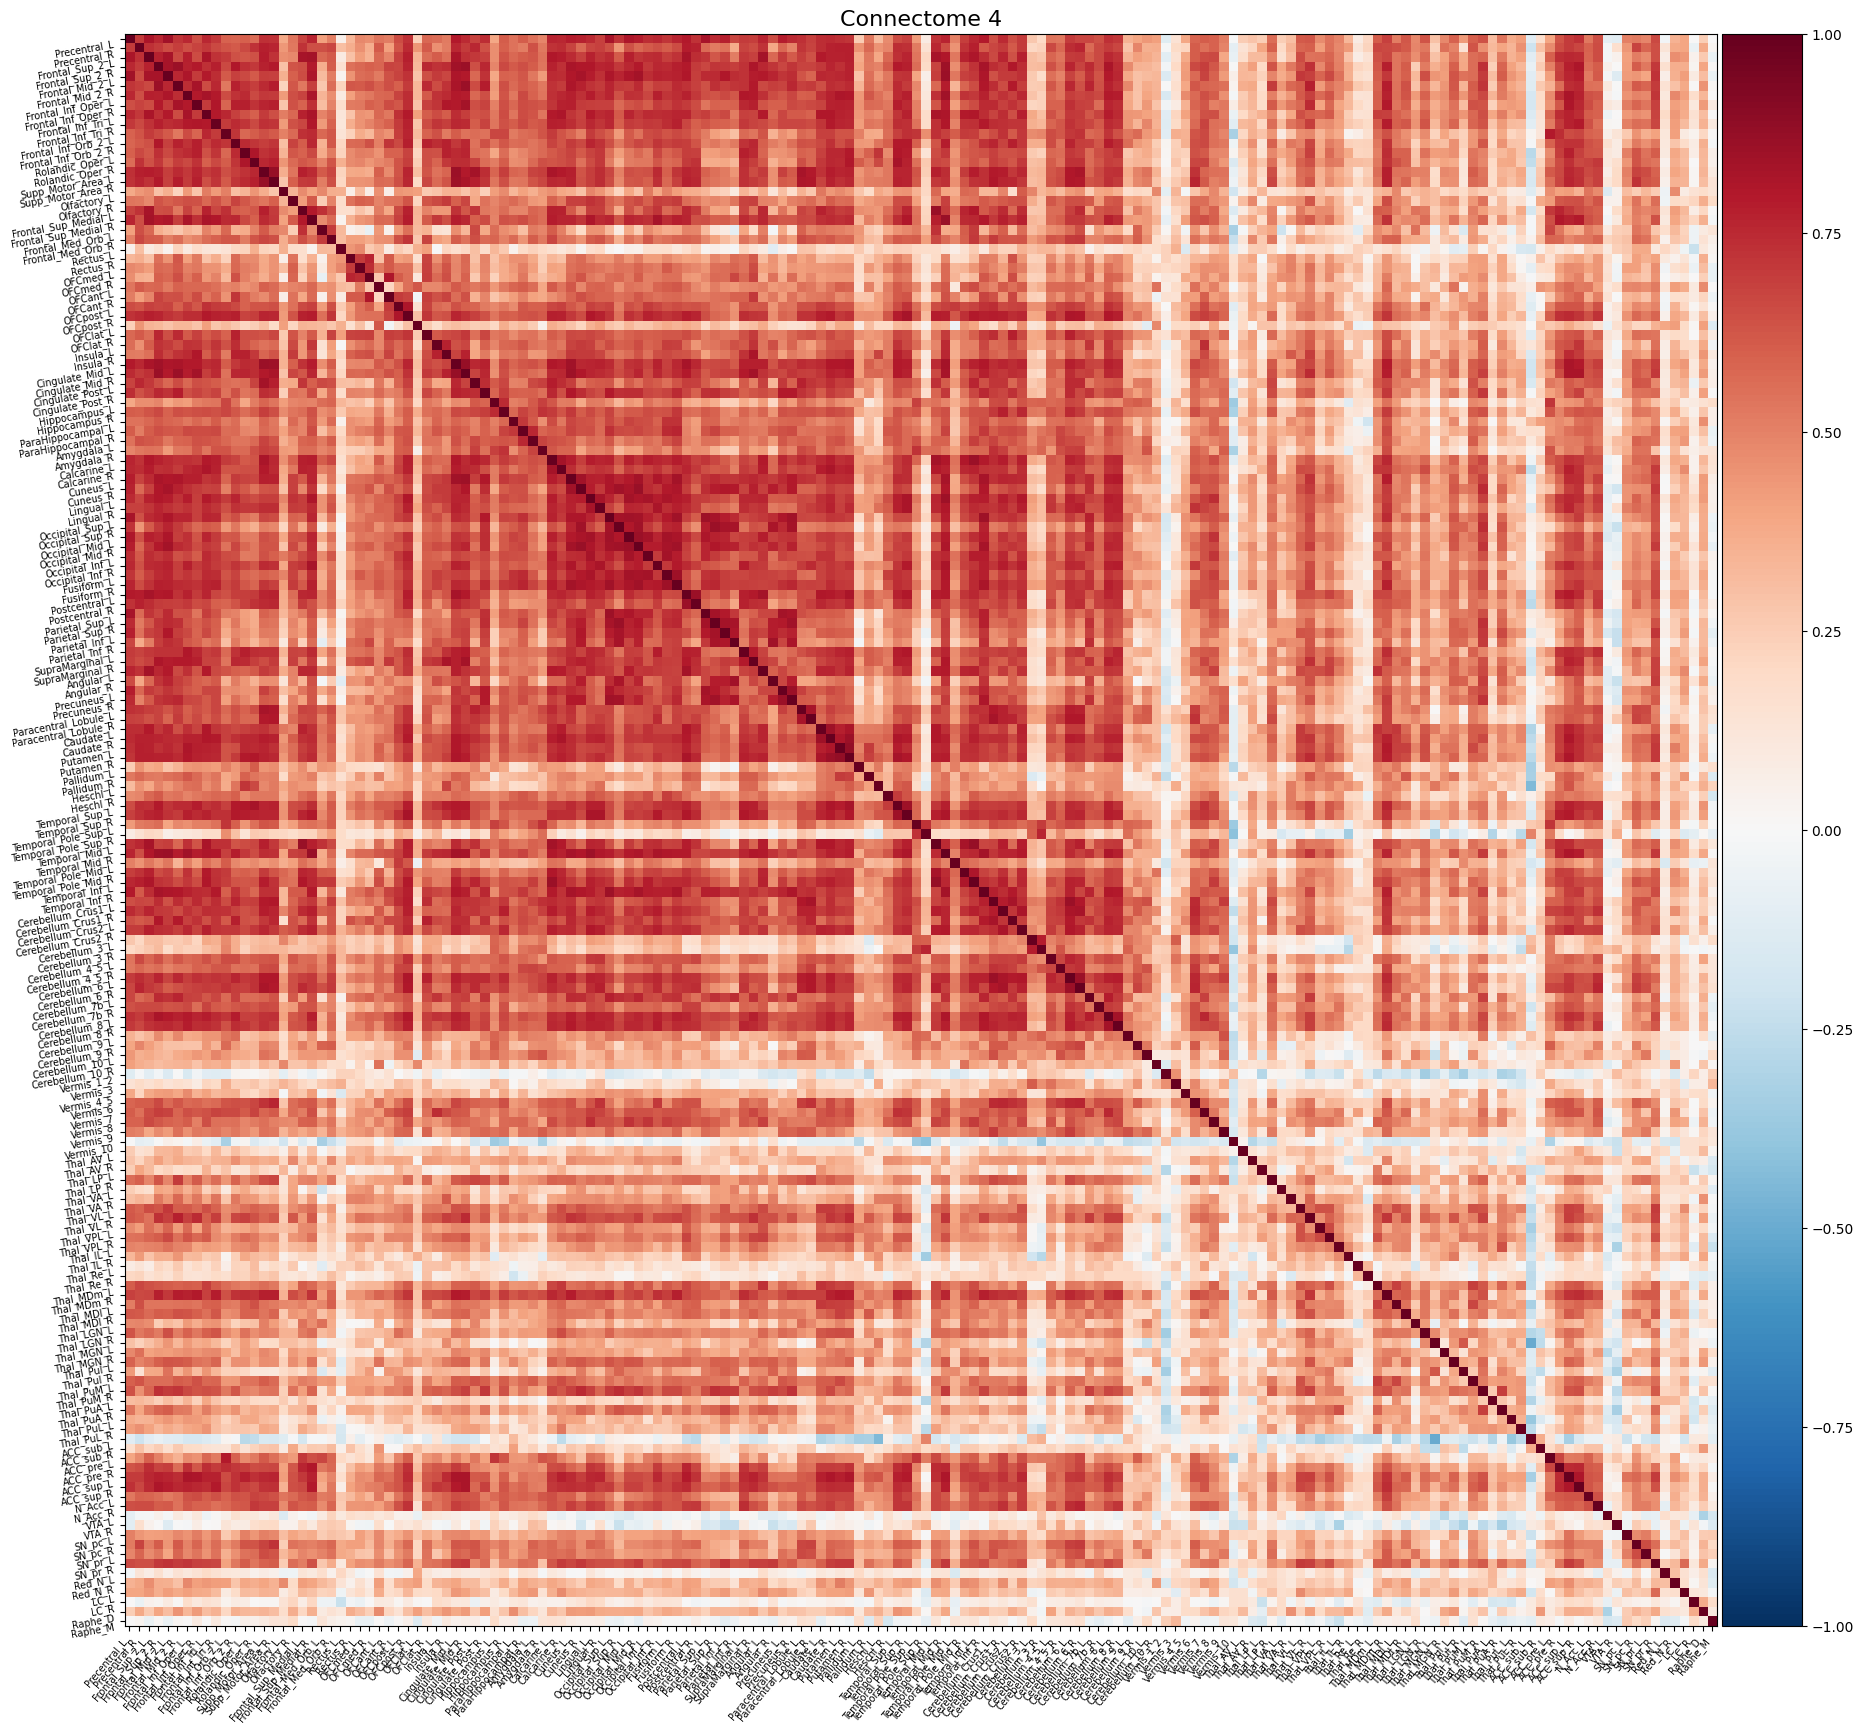

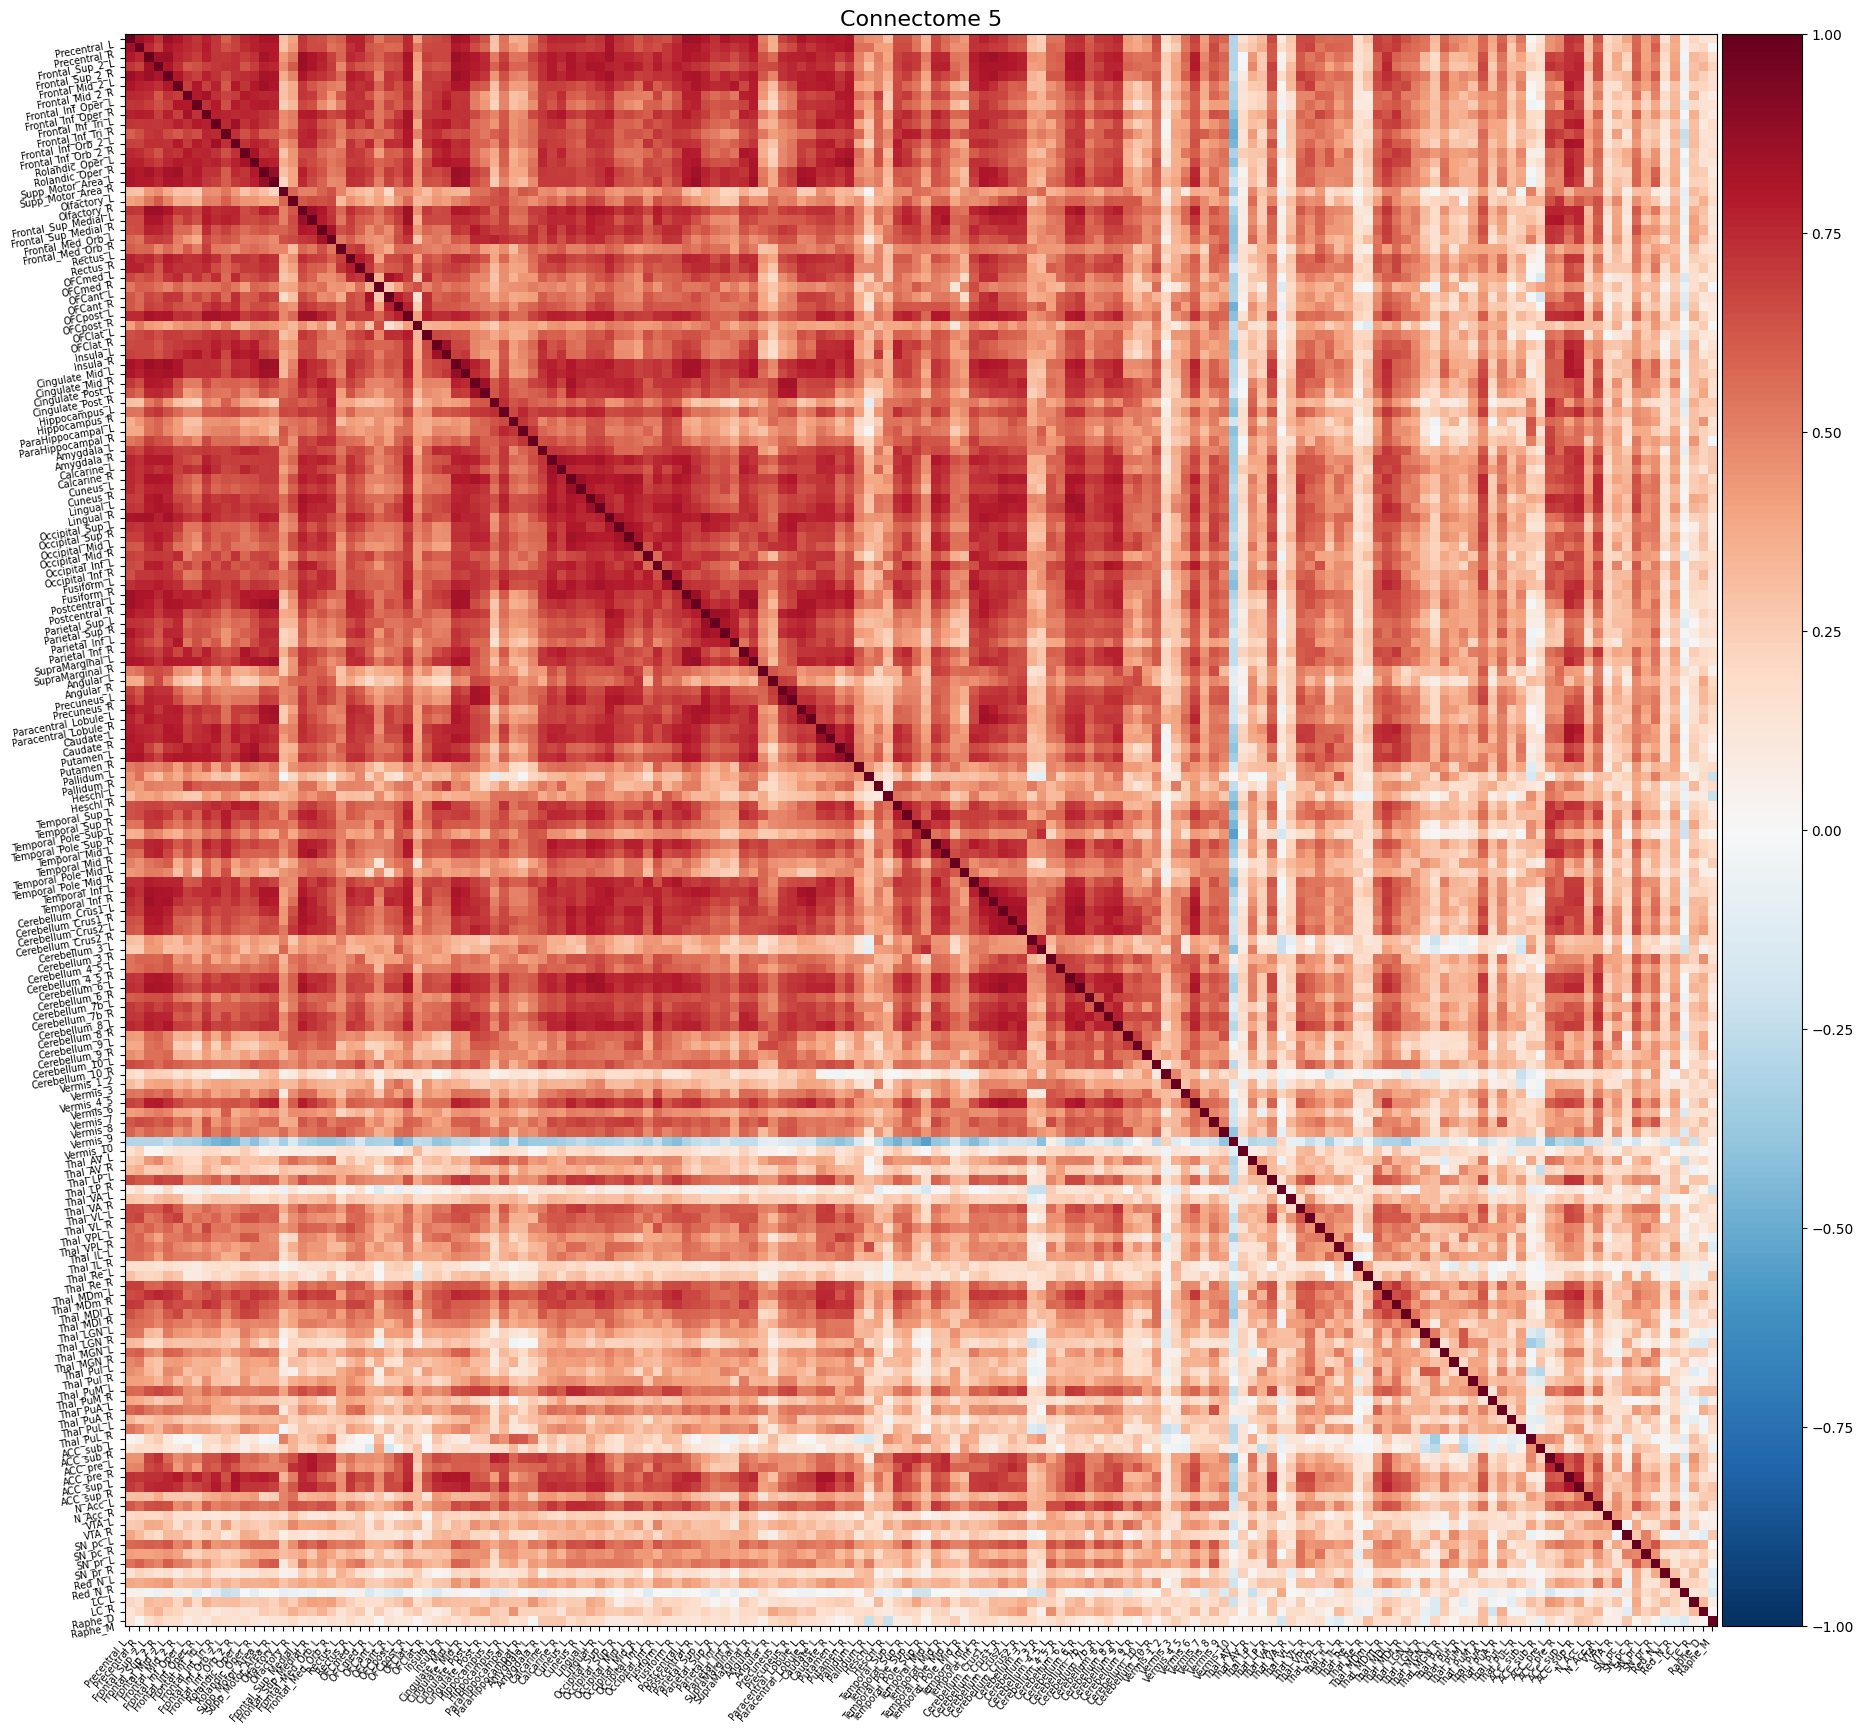

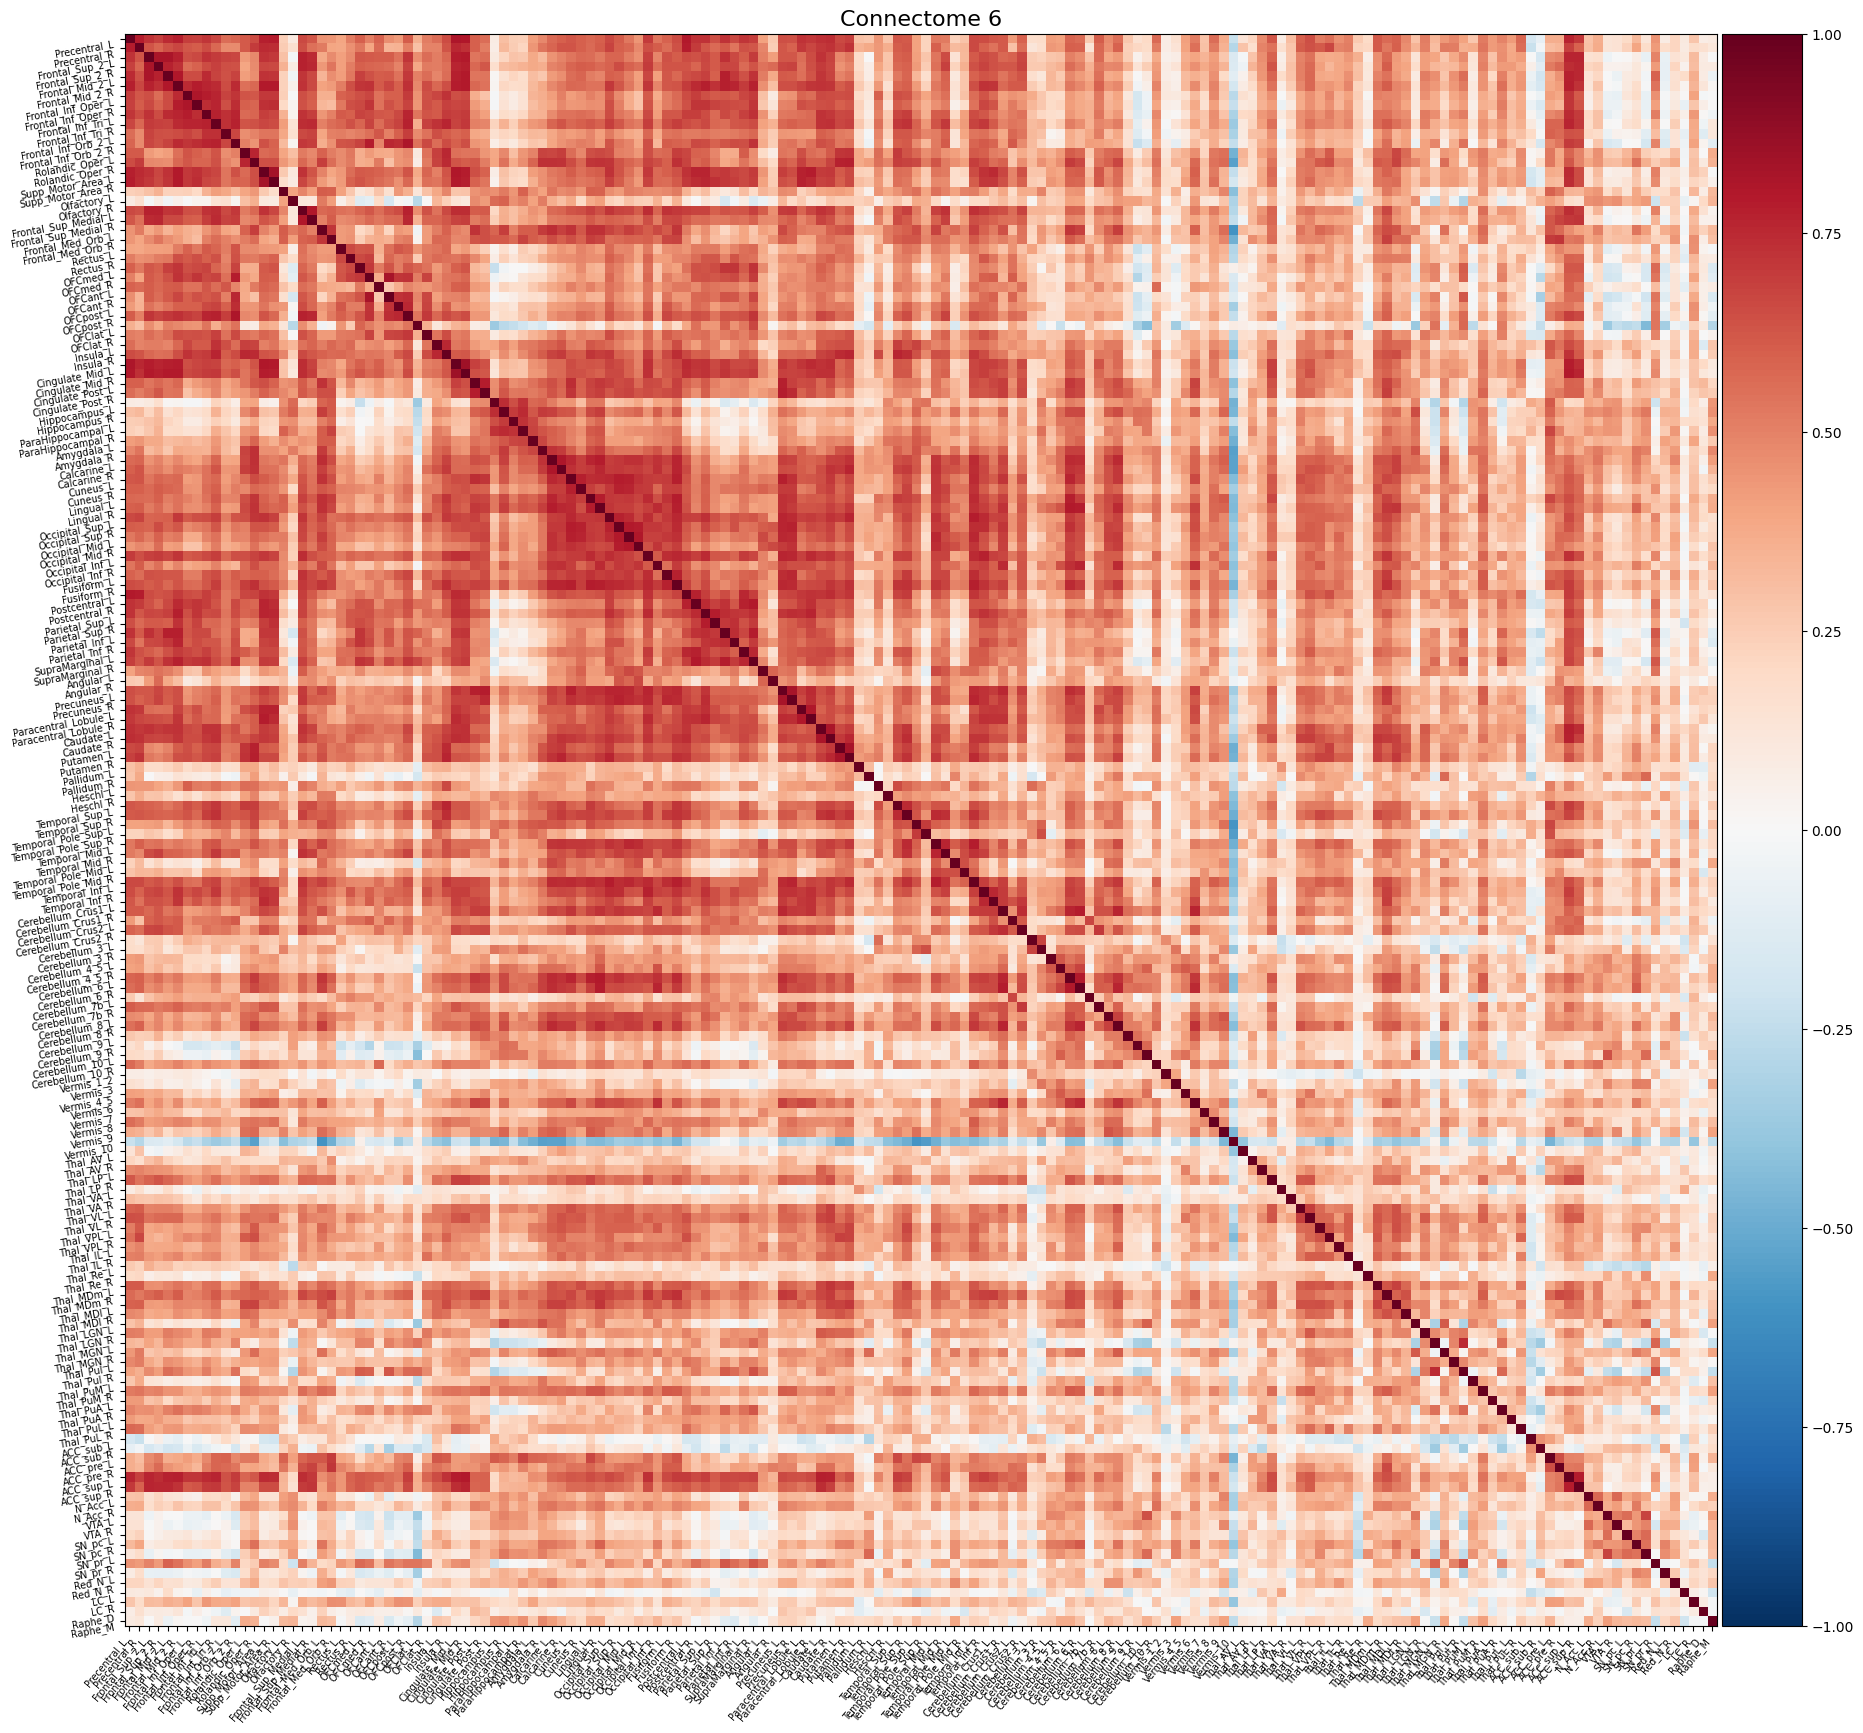

In [17]:
import matplotlib.pyplot as plt
for i, c in enumerate(connectome1):
    fig, ax = plt.subplots(figsize=(18, 18))
    plotting.plot_matrix(
        c,
        figure=fig,
        labels=aal.labels[1:],
        vmax=1,
        vmin=-1,
        title=f"Connectome {i}",
        reorder=False,
    )
    fig.savefig(f"connectome_{i}.png")
    

In [ ]:

# np.fill_diagonal(connectome1, 0)
# plotting.plot_matrix(
#     connectome1,
#     figure=(18, 18),
#     labels=aal.labels[1:],
#     vmax=1,
#     vmin=-1,
#     title="Confounds",
#     reorder=True,
# )
# print(connectome1.shape)

In [27]:
saved_fc = subject.get_fc_array()[0, :, :]
np.fill_diagonal(connectome1, 0)
print(connectome1.shape)
print(saved_fc.shape)
sum(saved_fc - connectome1)

(166, 166)
(166, 166)


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [34]:
from tqdm import tqdm
from pathlib import Path

fc_dir = Path("data/processed/fc")
if not fc_dir.exists():
    fc_dir.mkdir(parents=True)

for id, img, mask in tqdm(subject.enumerate_subjects()):
    fc_path = fc_dir / f"{id}.npy"
    if fc_path.exists():
        print(f"Skipping {id} because it already exists")
        continue
    connectome = compute_connectivity(img)
    np.fill_diagonal(connectome, 0)
    np.save(fc_dir / f"{id}.npy", connectome)

0it [00:00, ?it/s]

Skipping sub-1000804 because it already exists
Skipping sub-1023964 because it already exists
Skipping sub-1057962 because it already exists
Skipping sub-1099481 because it already exists
Skipping sub-1127915 because it already exists


186it [53:54, 17.39s/it]


In [15]:
import numpy as np
corr = subject.get_fc_array()
print(corr.shape)

# get upper triangular part
upper_tri = np.triu_indices(corr.shape[1], k=1)
corr_upper = corr[:, upper_tri[0], upper_tri[1]]

print(corr_upper.shape)

(186, 166, 166)
(186, 13695)


In [4]:
labels = subject.get_labels()
labels_merged = [0 if x == 0 else 1 for x in labels]
print(labels_merged)

[0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0]


In [8]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

svc = SVC(kernel="linear")
selector = RFE(estimator=svc, n_features_to_select=90, step=1)
selector = selector.fit(corr_upper, labels_merged)
print(selector.support_)
print(selector.ranking_)

[False False False ... False False False]
[7312 9443 8995 ...  311 7243 2496]


In [11]:
np.save("data/processed/NYU_feature_support.npy", np.where(selector.support_)[0])
np.save("data/processed/NYU_feature_ranking.npy", selector.ranking_)

In [ ]:
# get the selected features
selected_features = np.where(selector.support_)[0]
print(selected_features)

# get the selected features from the corr_upper
selected_corr_upper = corr_upper[:, selected_features]
print(selected_corr_upper.shape)

# save the selected features
np.save("data/processed/fc/selected_corr_upper.npy", selected_corr_upper)


[    6   534   617   916   990   994  1129  1156  1185  1425  1476  1555
  1597  1798  1799  1932  2091  2092  2292  2586  2657  2662  2674  2794
  2984  3237  3273  3311  3402  3406  3491  3677  3685  3689  3729  3761
  4184  4193  4234  4530  4634  4706  5686  5732  5944  6051  6604  7581
  7804  7928  7935  8135  8139  8507  8528  8590  8766  8923  9116  9207
  9235  9245  9275  9316  9367  9692  9774  9988  9993  9994 10016 10038
 10311 10710 10741 10821 10861 11007 11277 11586 11975 12032 12151 12209
 12213 12384 12396 12517 13279 13460]
(186, 90)


In [77]:
# create a rbf kernel and run classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

train_corr_upper, test_corr_upper, train_labels, test_labels = train_test_split(
    selected_corr_upper, labels_merged, test_size=0.2, random_state=42
)

svc = SVC(kernel="rbf")
svc.fit(train_corr_upper, train_labels)

predictions = svc.predict(test_corr_upper)

from sklearn.metrics import accuracy_score, classification_report

print(f"Accuracy: {accuracy_score(test_labels, predictions)}")
print(classification_report(test_labels, predictions))


Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        18
           1       0.91      1.00      0.95        20

    accuracy                           0.95        38
   macro avg       0.95      0.94      0.95        38
weighted avg       0.95      0.95      0.95        38



In [86]:
# 5-fold cross validation
from sklearn.model_selection import cross_validate


def run_cv(model, X, y):
    scores = cross_validate(model, X, y, cv=5, return_estimator=True)

    print(scores['test_score'])
    # mean
    mean_score = np.mean(scores['test_score'])
    print(f"Mean score: {mean_score}")
    return scores

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = run_cv(rf, selected_corr_upper, labels_merged)


svc = SVC(kernel="rbf")
svc_scores = run_cv(svc, selected_corr_upper, labels_merged)



[0.73684211 0.78378378 0.83783784 0.75675676 0.75675676]
Mean score: 0.7743954480796587
[0.94736842 0.97297297 0.94594595 0.97297297 0.83783784]
Mean score: 0.9354196301564723


In [84]:
print(scores['test_score'])
# find the best estimator
best_estimator = scores["estimator"][np.argmax(scores["test_score"])]
print(best_estimator)


[0.73684211 0.78378378 0.83783784 0.75675676 0.75675676]
RandomForestClassifier(random_state=42)


In [76]:
# find the top 10important features
importances = best_estimator.feature_importances_

print(len(importances))

# get the indices of the top 10 features
top_10_indices = np.argsort(importances)[-10:]

# get the top 10 features
top_10_features = selected_corr_upper[:, top_10_indices]

print(top_10_features.shape)

def flatten_idx_to_pair(flat_idx, upper_tri):
    """Convert flattened index to original (row, col) pair"""
    row = upper_tri[0][flat_idx]
    col = upper_tri[1][flat_idx]
    return row, col

index_pairs = [flatten_idx_to_pair(idx, upper_tri) for idx in top_10_indices]
print(index_pairs)



13695


IndexError: index 6911 is out of bounds for axis 1 with size 90

In [14]:
image_dir = "data/raw"
preprocessed_dir = "data/processed"
NEURO_dataset = SubjectDataset(image_dir=image_dir, label_path=preprocessed_dir + "/NEURO_labels.csv", fc_dir=preprocessed_dir + "/fc")

NEURO_dataset.get_fc_array().shape

(20, 116, 116)

In [8]:
import pandas as pd

df = pd.read_csv("data/processed/NYU_labels.csv")
df.head()

# get the value counts of the label, group 1,2,3 together as 1  
df["label"].value_counts()


label
0    83
1    62
3    39
2     2
Name: count, dtype: int64